In [85]:
# Import the packages needed for the notebook

import pandas as pd
import matplotlib.pyplot as plt

# Show all columns when viewing the dataset
pd.set_option("display.max_columns", None)

In [87]:
# Load the dataset
data = pd.read_csv("data/Short_Term_Rentals.csv")
# Show the first few rows
data.head()

Reusable Functions:

In [114]:
# Cleaning function: converts date columns to datetime

def clean_dates(df):
    df["Licenced Date"] = pd.to_datetime(df["Licenced Date"], errors="coerce")
    df["Licenced Expiry Date"] = pd.to_datetime(df["Licenced Expiry Date"], errors="coerce")
    return df

# Example 1: Clean the full dataset

data = clean_dates(data)

# Example 2: Clean a filtered subset (first 100 rows)

subset = clean_dates(data.head(100))

subset.head()

/var/folders/0n/3hsy5lhs1zxfqgz3gpg7m5nc0000gn/T/ipykernel_68640/1206360025.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Licenced Date"] = pd.to_datetime(df["Licenced Date"], errors="coerce")
/var/folders/0n/3hsy5lhs1zxfqgz3gpg7m5nc0000gn/T/ipykernel_68640/1206360025.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Licenced Expiry Date"] = pd.to_datetime(df["Licenced Expiry Date"], errors="coerce")


,Business Licence Number,Business ID,Address,Business Licence Type,Type of Residence,Licenced Date,Licenced Expiry Date,Status Description,longitude,latitude,Point,Year
0,BL281333,16500233,5507 6 ST SW,SHORT TERM RENTAL - PRIMARY RESIDENCE,Townhouse,2025-11-25 15:37:02,2026-11-25 15:37:02,Licensed,-114.079140,51.004838,POINT (-114.07913980634427 51.004838029647),2025
1,BL291031,16618837,2032B 5 AV NW,SHORT TERM RENTAL - NON-PRIMARY RESIDENCE,Townhouse,2025-05-06 15:10:43,2026-05-06 15:10:43,Expired,-114.107498,51.057394,POINT (-114.10749848959601 51.057394359075815),2025
2,BL270921,16360000,19G PRESTWICK CV SE,SHORT TERM RENTAL - NON-PRIMARY RESIDENCE,Single/detached house,2025-07-08 22:03:52,2026-07-08 22:03:52,Licensed,NaN,NaN,NaN,2025
3,BL287213,16570921,3232D 19 AV SE,SHORT TERM RENTAL - PRIMARY RESIDENCE,Duplex/triplex,2026-02-18 10:18:57,2027-02-18 10:18:57,Licensed,NaN,NaN,NaN,2026
4,BL300131,16724288,1147 9 ST SE,SHORT TERM RENTAL - NON-PRIMARY RESIDENCE,Apartment/condo unit,2026-01-22 12:46:18,2027-01-22 12:46:18,Licensed,NaN,NaN,NaN,2026


In [112]:
# Add year column function for filtering

def add_year_column(df):
    df["Year"] = df["Licenced Date"].dt.year
    return df

# Example 1: Add year column to full dataset

data = add_year_column(data)

# Example 2: Add year column to a filtered subset

subset = add_year_column(data.head(50))

subset.head()

/var/folders/0n/3hsy5lhs1zxfqgz3gpg7m5nc0000gn/T/ipykernel_68640/3501931557.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Year"] = df["Licenced Date"].dt.year


,Business Licence Number,Business ID,Address,Business Licence Type,Type of Residence,Licenced Date,Licenced Expiry Date,Status Description,longitude,latitude,Point,Year
0,BL281333,16500233,5507 6 ST SW,SHORT TERM RENTAL - PRIMARY RESIDENCE,Townhouse,2025-11-25 15:37:02,2026-11-25 15:37:02,Licensed,-114.079140,51.004838,POINT (-114.07913980634427 51.004838029647),2025
1,BL291031,16618837,2032B 5 AV NW,SHORT TERM RENTAL - NON-PRIMARY RESIDENCE,Townhouse,2025-05-06 15:10:43,2026-05-06 15:10:43,Expired,-114.107498,51.057394,POINT (-114.10749848959601 51.057394359075815),2025
2,BL270921,16360000,19G PRESTWICK CV SE,SHORT TERM RENTAL - NON-PRIMARY RESIDENCE,Single/detached house,2025-07-08 22:03:52,2026-07-08 22:03:52,Licensed,NaN,NaN,NaN,2025
3,BL287213,16570921,3232D 19 AV SE,SHORT TERM RENTAL - PRIMARY RESIDENCE,Duplex/triplex,2026-02-18 10:18:57,2027-02-18 10:18:57,Licensed,NaN,NaN,NaN,2026
4,BL300131,16724288,1147 9 ST SE,SHORT TERM RENTAL - NON-PRIMARY RESIDENCE,Apartment/condo unit,2026-01-22 12:46:18,2027-01-22 12:46:18,Licensed,NaN,NaN,NaN,2026


In [108]:
# Filtering function: filter by year

def filter_by_year(df, year):
    return df[df["Year"] == year]

# Dynamically get the two most recent years in the dataset
recent_years = sorted(data["Year"].dropna().unique())[-2:]
year_1, year_2 = int(recent_years[0]), int(recent_years[1])

# Example 1: Filter for the most recent year
rentals_year1 = filter_by_year(data, year_1)
print(f"{year_1} rentals:", len(rentals_year1))

# Example 2: Filter for the second most recent year
rentals_year2 = filter_by_year(data, year_2)
print(f"{year_2} rentals:", len(rentals_year2))


In [110]:
# Summary function: count values in any column

def count_by_column(df, column):
    return df[column].value_counts()

# Example 1: Count licence status values

print(count_by_column(data, "Status Description"))

# Example 2: Count residence types

print(count_by_column(data, "Type of Residence"))

Status Description
Licensed                            3589
Expired                              230
Closed                               202
Expired - Pending Recommendation      35
Cancelled                             19
Cancelled - Pending Confirmation       1
Name: count, dtype: int64
Type of Residence
Legally registered suite    1100
Single/detached house       1018
Apartment/condo unit         960
Duplex/triplex               323
Townhouse                    272
A bedroom in the home        259
Suite in a house              97
Coach/lane house              47
Name: count, dtype: int64


In [106]:
#Function to filter by Status

def filter_by_status(df, status):
    return df[df["Status Description"] == status]

# Example 1: Active licences

active = filter_by_status(data, "Licensed")
print("Active licences:", len(active))

# Example 2: Expired licences

expired = filter_by_status(data, "Expired")
print("Expired licences:", len(expired))

Active licences: 3589
Expired licences: 230


In [100]:
#Function for plot bar 

def plot_bar(df, column, title, color="steelblue"):
    counts = count_by_column(df, column)
    plt.figure(figsize=(8, 4))
    counts.plot(kind="barh", color=color)
    plt.xlabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [104]:
#Function for KPI

def show_kpis(df):
    total       = len(df)
    active      = len(filter_by_status(df, "Licensed"))
    expired     = len(filter_by_status(df, "Expired"))
    primary     = len(df[df["Business Licence Type"] == "SHORT TERM RENTAL - PRIMARY RESIDENCE"])
    non_primary = len(df[df["Business Licence Type"] == "SHORT TERM RENTAL - NON-PRIMARY RESIDENCE"])

    print("Total listings       :", total)
    print("Active (Licensed)    :", active,      f"({round(active / total * 100, 1)}%)")
    print("Expired              :", expired,     f"({round(expired / total * 100, 1)}%)")
    print("Primary residence    :", primary,     f"({round(primary / total * 100, 1)}%)")
    print("Non-primary residence:", non_primary, f"({round(non_primary / total * 100, 1)}%)")

# Example 1: KPIs for all licences
print("=== KPIs – All Licences ===")
show_kpis(data)

# Example 2: KPIs for the most recent year only
print(f"
=== KPIs – {year_2} Licences ===")
show_kpis(filter_by_year(data, year_2))


Questions and Answers:

In [54]:
# 1: How many licences were issued in the two most recent years?

rentals_year1 = filter_by_year(data, year_1)
rentals_year2 = filter_by_year(data, year_2)

print(f"Licences issued in {year_1}:", len(rentals_year1))
print(f"Licences issued in {year_2}:", len(rentals_year2))

year_counts = pd.Series({year_1: len(rentals_year1), year_2: len(rentals_year2)})
plt.figure(figsize=(5, 3))
year_counts.plot(kind="bar", color=["steelblue", "orange"])
plt.title(f"Licences Issued – {year_1} vs {year_2}")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Status Description
Licensed                            3589
Expired                              230
Closed                               202
Expired - Pending Recommendation      35
Cancelled                             19
Cancelled - Pending Confirmation       1
Name: count, dtype: int64


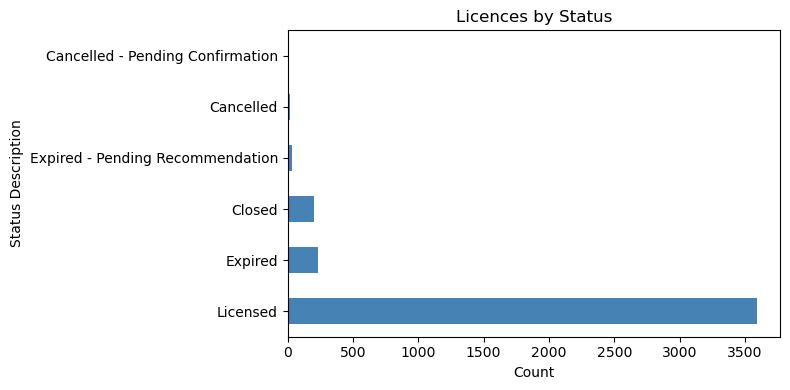

In [56]:
# 2: How many licences are Active vs. Expired vs Closed?

status_counts = data["Status Description"].value_counts()
print(status_counts)

plot_bar(data, "Status Description", "Licences by Status")

Type of Residence
Legally registered suite    1100
Single/detached house       1018
Apartment/condo unit         960
Duplex/triplex               323
Townhouse                    272
A bedroom in the home        259
Suite in a house              97
Coach/lane house              47
Name: count, dtype: int64


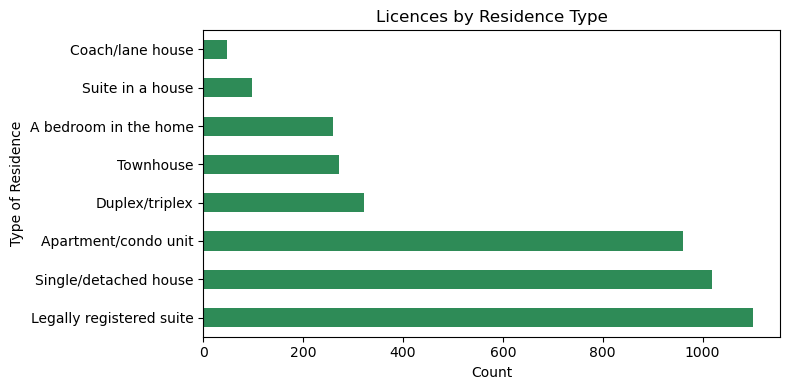

In [58]:
#3: Which type of residence is most commonly used for short-term rentals?

residence_counts = data["Type of Residence"].value_counts()
print(residence_counts)

plot_bar(data, "Type of Residence", "Licences by Residence Type", color="seagreen")

Type of Residence
Legally registered suite    1100
Single/detached house       1018
Apartment/condo unit         960
Duplex/triplex               323
Townhouse                    272
A bedroom in the home        259
Suite in a house              97
Coach/lane house              47
Name: count, dtype: int64


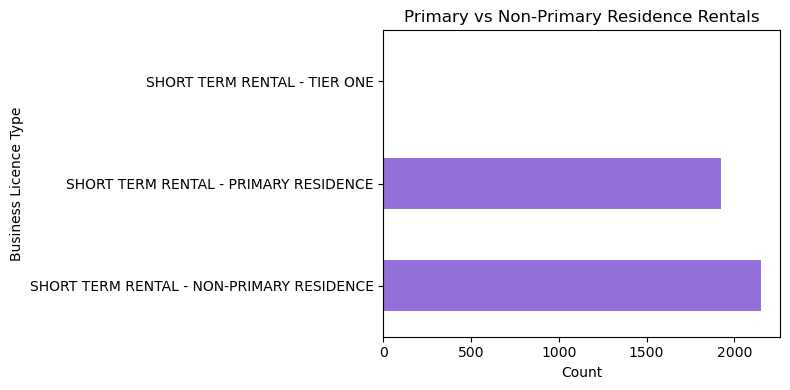

In [60]:
#4: Are there more primary-residence rentals or non-primary-residence rentals?

primary_counts = data["Type of Residence"].value_counts()
print(primary_counts)

plot_bar(data, "Business Licence Type", "Primary vs Non-Primary Residence Rentals", color="mediumpurple")

Expired without renewal (%): 5.6


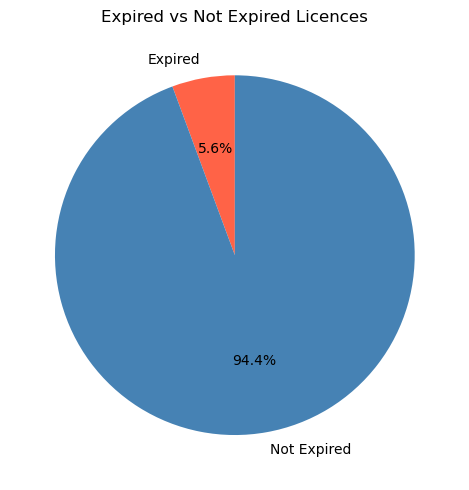

In [116]:
# Q5: What percentage of rentals have expired without renewal?

expired = len(filter_by_status(data, "Expired"))
total   = len(data)

print("Expired without renewal (%):", round((expired / total) * 100, 1))

not_expired = total - expired

plt.figure(figsize=(5, 5))
plt.pie([expired, not_expired], labels=["Expired", "Not Expired"], colors=["tomato", "steelblue"], autopct="%1.1f%%", startangle=90)
plt.title("Expired vs Not Expired Licences")
plt.tight_layout()
plt.show()